In [ ]:
import os
import yaml
import datasets
import torch
import random
import numpy as np
import torch.optim as optim
from torch.utils.data import  DataLoader
from torch.amp import GradScaler, autocast
from transformers import AutoTokenizer, get_linear_schedule_with_warmup

from scripts.data_utils import eda, create_label_mapping, tokenize_and_align_labels, JointNERDataset, JointCollator, sanity_check_batch
from scripts.eval import evaluate, run_inference
from scripts.model import JointModel

In [12]:
def load_config(config_path='configs/config.yaml'):
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Конфигурационный файл не найден по пути: {config_path}")
    
    try:
        with open(config_path, "r", encoding="utf-8") as f:
            config = yaml.safe_load(f)
            
        if config is None:
            raise ValueError("Файл конфигурации пуст")
            
        return config

    except yaml.YAMLError as e:
        print(f"Ошибка в синтаксисе YAML: {e}")
        raise
    except Exception as e:
        print(f"Ошибка при загрузке: {e}")
        raise
    
try:
    cfg = load_config()
    print("Конфигурационный файл успешно загружен")
    print(f"Список ключей верхнего уровня конфигурации: {[key for key in cfg.keys()]}")
except Exception as e:
    print(f"Не удалось запустить: {e}")

Конфигурационный файл успешно загружен
Список ключей верхнего уровня конфигурации: ['data', 'model']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print('CUDA available:', torch.cuda.is_available());
if torch.cuda.is_available():
    print('Current device:', torch.cuda.get_device_name(0))

CUDA available: True
Current device: Tesla T4


In [ ]:
def seed_everything(seed: int):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(42)

In [ ]:
ds = datasets.load_dataset(cfg["data"]["dataset_name"])["train"]

Запись 1

Текст: Пулеметы, автоматы и снайперские винтовки изъяты в арендуемом американцами доме в Бишкеке 05/08/2008...
Токены: ['Пулеметы,', 'автоматы', 'и', 'снайперские', 'винтовки', 'изъяты', 'в']...
NER теги: ['O', 'O', 'O', 'O', 'O', 'O', 'O']...
CLS вектор: [1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0]

Запись 2

Текст: Муртаза Рахимов чистит кадры Президент Башкирии Муртаза Рахимов в очередной раз решил поменять главу...
Токены: ['Муртаза', 'Рахимов', 'чистит', 'кадры', 'Президент', 'Башкирии', 'Муртаза']...
NER теги: ['B-PERSON', 'I-PERSON', 'O', 'O', 'B-PROFESSION', 'I-PROFESSION', 'B-PERSON']...
CLS вектор: [1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]

Запись 3

Текст: Россия задерживает поставку генсека Сегодня в Дохе открывается заседание Форума стран-экспортеров га...
Токены: ['Россия', 'задерживает', 'поставку', 'генсека', 'Сегодня', 'в', 'Дохе']...
NER теги: ['B-COUNTRY', 'O', 'O

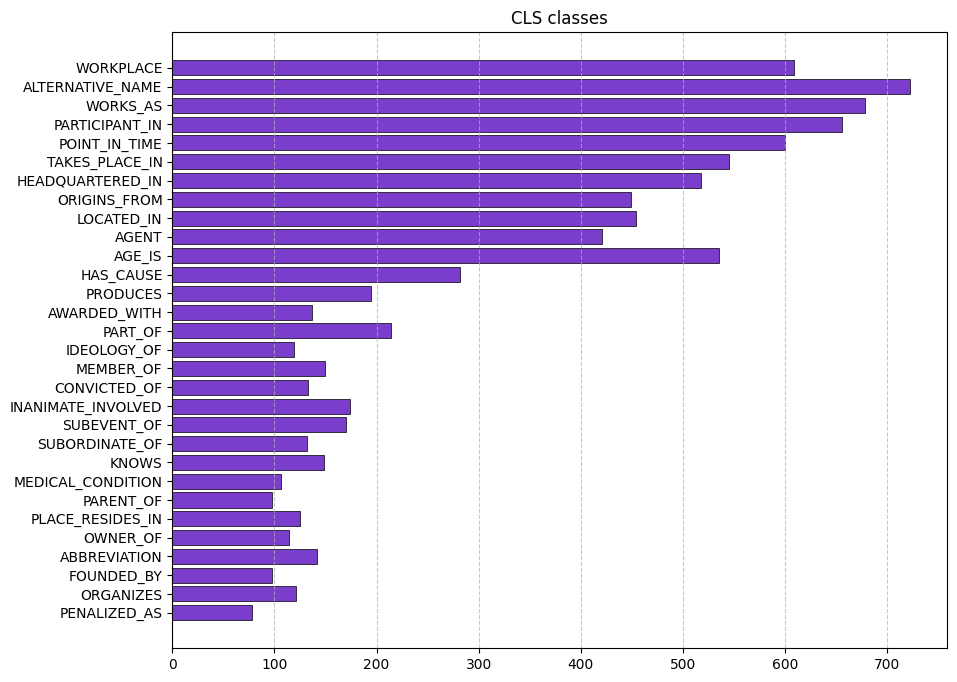

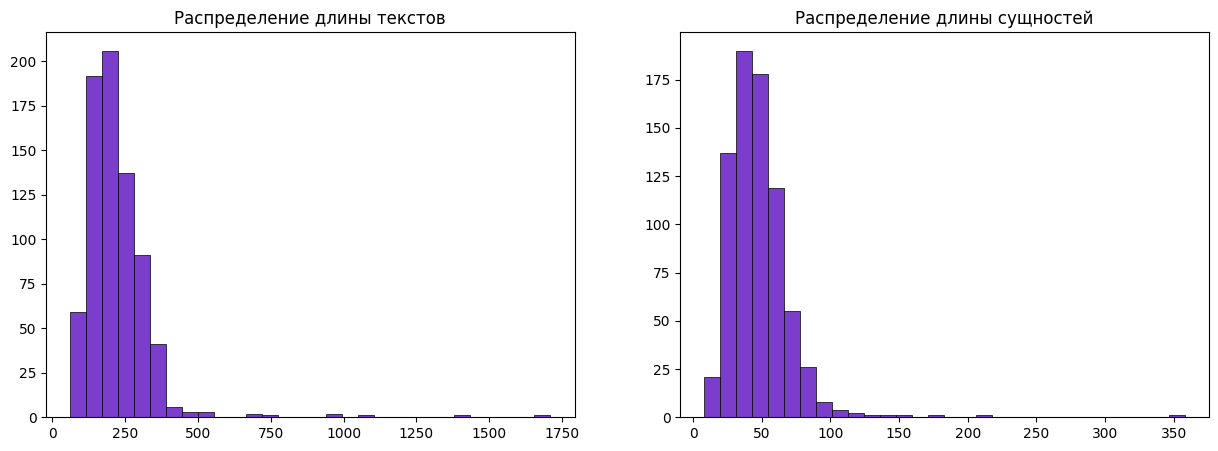

interval columns not set, guessing: ['WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME', 'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS']


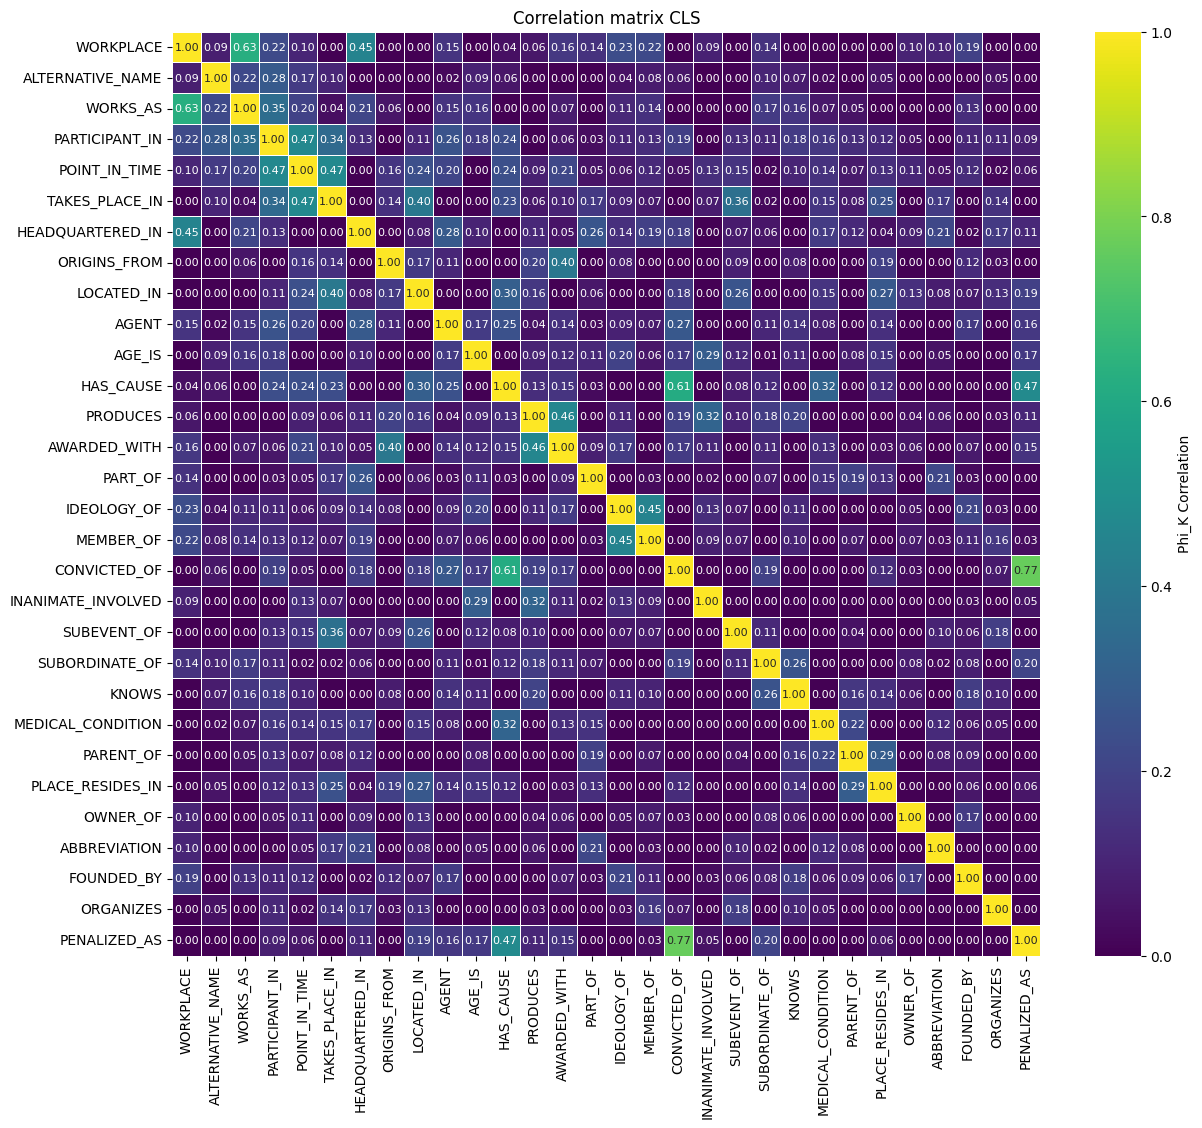

In [5]:
classes = ['WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME', 
           'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 
           'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 
           'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 
           'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 
           'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS']

eda(ds, classes)

## Выводы по EDA:

#### 1. За счет матрицы корреляции мы понимаем, что задачи NER и классификации действительно имеют обзую структуру, например, выявлена сильная корреляция между *PENIZED_AS* и *CONVICTED_OF*. Общий encoder позволит нашей модели лучше(быстрее и дешевле) формировать представления о каждой новости.

#### 2. Средняя плотность данных +-12, а также, в среднем, у нас около 50 сущностей на документ, это говорит о том, что наши данные довольно насыщены. Из-за этого мы может сделать несколько выводов: модель не будет страдать от нехватки признаков, однако, нам будет необходимо довольно емкая модель, чтобы удержать все эти связи(В планах использовать **DeepPavlov/rubert-base-cased**, выбираю именно cased, поскольку нам важно учитывать заглавные буквы, довольно важный маркер для NER).

#### 3. Большинство текстов имеют длину от 150 до 300 токенов. Это позволяет использовать стандартный лимит rubert в 512 токенов без потери важной информации при обрезке текста. Данные однородны, аномальные выбросы практически отсутствуют.

#### 4. Наблюдается значительный дисбаланс классов: самые частые события встречаются в 10 раз чаще редких. Чтобы модель не игнорировала редкие классы, необходимо использовать взвешенную функцию потерь. Это обеспечит стабильность классификации даже для специфических категорий новостей.

# Токенизация, выравнивание меток и DataLoader

In [ ]:
model_name = "DeepPavlov/rubert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
collator = JointCollator(tokenizer)
label2id, id2label = create_label_mapping(ds)

split_ds = ds.train_test_split(test_size=0.15, seed=42)
val_test_split = split_ds["train"].train_test_split(test_size=0.15, seed=42)
dataset = datasets.DatasetDict({
    "train": val_test_split["train"],
    "val": val_test_split["test"],
    "test": split_ds["test"]
})

tokenized_dataset = dataset.map(
    lambda x: tokenize_and_align_labels(x, tokenizer, label2id, max_length=512),
    batched=True,
    remove_columns=dataset["train"].column_names
)

train_dataloader =  DataLoader(
    JointNERDataset(tokenized_dataset["train"]),
    batch_size=16,
    shuffle=True,
    collate_fn=collator
)
val_dataloader = DataLoader(
    JointNERDataset(tokenized_dataset["val"]),
    batch_size=16,
    shuffle=False,
    collate_fn=collator
)
test_dataloader = DataLoader(
    JointNERDataset(tokenized_dataset["test"]),
    batch_size=16,
    shuffle=False,
    collate_fn=collator
)


print(f"Train batches: {len(train_dataloader)}")
print(f"Val batches: {len(val_dataloader)}")
print(f"Test: {len(test_dataloader)}")

sanity_check_batch(val_dataloader, tokenizer, id2label, num_examples=1)

/home/ubuntu/.venv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Train batches: 34
Val batches: 6
Test: 7


Размерности тензоров


Input ids shape: torch.Size([16, 396])
Attention Mask: torch.Size([16, 396])
NER labels shape: torch.Size([16, 396])
CLS labels shape: torch.Size([16, 30])



Пример 1

Вектор классификации: [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0]
Token                | Label ID   | Tag
[CLS]                  -100         IGNORE
Путин                  22           B-PERSON
наградил               8            B-EVENT
Киселёва               22           B-PERSON
орденом                57           O
«                      1            B-AWARD
За                     -100         IGNORE
заслуги                30           I-AWARD
перед                  30           I-AWARD
Отечеством             30           I-AWARD
»                      -100         IGNORE
Владимир               22           B-PERSON
Киселёв                50           I-PERSON
Орден                  57           O
«                      1            B-AWARD
За 

# Training / Validation

In [ ]:
model = JointModel(
    model_name=model_name, 
    label2id=label2id, 
    id2label=id2label, 
    num_cls_labels=30, 
    use_uncertainty_weight=True
).to(device)

num_epochs = 20
max_grad_norm = 1.0


no_decay = ["bias", "LayerNorm.weight", "log_sigma"]
optimizer_grouped_parameters = [
    # BERT с Weight Decay
    {
        "params": [p for n, p in model.model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01,
        "lr": 2e-5
    },
    # BERT без Weight Decay
    {
        "params": [p for n, p in model.model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
        "lr": 2e-5
    },
    # Головы с Weight Decay для регуляризации
    {
        "params": [p for n, p in model.named_parameters() if "model" not in n and not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01,
        "lr": 1e-4
    },
    # Головы без Weight Decay: bias, log_sigma
    {
        "params": [p for n, p in model.named_parameters() if "model" not in n and any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
        "lr": 1e-4
    }
]
optimizer = optim.AdamW(optimizer_grouped_parameters)

scaler = GradScaler()

# Для ReduceLROnPlateau

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5,
    patience=2,
    threshold=0.001,
    verbose=False
)

# Для get_linear_schedule_with_warmup

# total_steps = len(train_dataloader) * num_epochs
# warmup_steps = total_steps * 0.1
# scheduler = get_linear_schedule_with_warmup(
#     optimizer=optimizer,
#     num_training_steps=total_steps,
#     num_warmup_steps=warmup_steps
# )

In [ ]:
best_val_loss = float("inf")
best_cls_f1 = 0.0
counter = 0
patience = 5
early_stop = False

print(f"{'Epoch':<8} | {'Train Loss':<10} | {'Val Loss':<10} | {'Token F1':<10} | {'CLS F1':<10}")
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        optimizer.zero_grad()
        
        with autocast(device_type="cuda" if torch.cuda.is_available() else "cpu"):
            outputs = model(**batch)
            loss = outputs["loss"]
        
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        
        scaler.step(optimizer)
        # scheduler.step() При использовании get_linear_schedule_with_warmup
        scaler.update()
        
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_dataloader)
    val_loss, token_f1, cls_f1 = evaluate(model, val_dataloader, device)
    
    scheduler.step(val_loss) # При использовании ReduceLROnPlateau
    
    print(f"{epoch+1:<10} {avg_train_loss:<12.4f} {val_loss:<12.4f} {token_f1:<12.4f} {cls_f1:<12.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            early_stop = True
    if early_stop:
        break
    
    if  cls_f1 > best_cls_f1:
        best_cls_f1 = cls_f1
        torch.save(model.state_dict(), "best_joint_model.pth")

Epoch    | Train Loss | Val Loss   | Token F1   | CLS F1    
1          3.0814       2.1920       0.0774       0.7041      
2          1.8857       1.5943       0.2609       0.7290      
3          1.4896       1.3448       0.3956       0.7438      
4          1.2688       1.2219       0.4677       0.7482      
5          1.1170       1.1518       0.5033       0.7737      
6          1.0068       1.0922       0.5442       0.7872      
7          0.9174       1.0885       0.5794       0.7841      
8          0.8418       1.0543       0.6113       0.7852      
9          0.7791       1.0258       0.6394       0.7989      
10         0.7148       1.0184       0.6628       0.8051      
11         0.6531       1.0121       0.6839       0.8016      
12         0.6047       1.0118       0.6751       0.8085      
13         0.5497       1.0283       0.6917       0.7912      
14         0.5010       1.0335       0.6923       0.8007      
15         0.4415       1.0192       0.7021       0.8107 

#### Совместное обучение двух голов на базе пулинга Mean+Max и динамического взвешивания потерь доказало свою эффективность, выдав стабильное качество распознавания на финальных этапах.

1. Успешное достижение целевых порогов: Модель нащупала оптимальный баланс для Joint-задачи на 15-й эпохе, показав пиковые метрики качества: 0.7021 token f1 и 0.8107 cls f1.

2. Эффективность стратегии оптимизации: Дифференциальный Learning Rate (2e-5 для тела RuBERT и 1e-4 для голов) в сочетании с исключением весов лосса из Weight Decay позволил подтянуть отстающую NER-задачу без разрушения предобученных признаков базовой модели.

3. Стабилизация обучения: Планировщик ReduceLROnPlateau и Weight Decay для классификаторов успешно удержали Val Loss на минимальном плато (+-1.01) вплоть до 12-15 эпох, минимизировав эффект взрывного переобучения.

# Инференс, квантизация и анализ ошибок

In [ ]:
eval_model = JointModel(
    model_name=model_name, 
    label2id=label2id, 
    id2label=id2label, 
    num_cls_labels=30, 
    use_uncertainty_weight=True
)


state_dict = torch.load("models/best_joint_model.pth", map_location="cpu")
eval_model.load_state_dict(state_dict)

eval_model = eval_model.to("cpu")
eval_model.eval()

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/tmp/ipykernel_8625/159573222.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the cu

JointModel(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_

In [ ]:
sample = next(iter(test_dataloader))

print("Исходная модель:")

time_eval_model = run_inference(sample, eval_model, tokenizer, "cpu", id2label, classes)

print(f"\nВремя инференса батча на CPU(eval_model): {time_eval_model:.4f} сек\n")

print(f"\n{'=' * 70}\n")

print("Квантованная модель:")

quantized_model = torch.quantization.quantize_dynamic(
    eval_model, 
    {torch.nn.Linear}, 
    dtype=torch.qint8
)

time_quantized_model = run_inference(sample, quantized_model, tokenizer, "cpu", id2label, classes)
print(f"\nВремя инференса батча на CPU(quantized model): {time_quantized_model:.4f} сек")
print(f"Ускорение инференса: {time_eval_model / time_quantized_model:.2f}x")

Исходная модель:
CLS probabilities:
  WORKPLACE: 0.9909
  WORKS_AS: 0.9804
  ALTERNATIVE_NAME: 0.9512
  HEADQUARTERED_IN: 0.9069
  AGE_IS: 0.8496
  PARTICIPANT_IN: 0.4358
  ORIGINS_FROM: 0.3547
  IDEOLOGY_OF: 0.3448
  PART_OF: 0.3305
  MEMBER_OF: 0.2950

Token predictions:
  Число                : O             | True: O
  кандидатов           : O             | True: O
  в                    : O             | True: O
  мэры                 : I-PROFESSION  | True: B-PROFESSION
  Москвы               : I-PROFESSION  | True: I-PROFESSION
  выросло              : O             | True: O
  до                   : O             | True: O
  13                   : B-NUMBER      | True: B-NUMBER
  Тринадц              : B-NUMBER      | True: B-ORDINAL
  кандидатом           : O             | True: O
  на                   : O             | True: O
  пост                 : O             | True: O
  столичного           : B-PROFESSION  | True: B-PROFESSION
  градоначальника      : I-PROFESSION  | 

## Вывод по этапу инференса и квантизации

##### 1. Производительность на CPU: Скорость обработки токенов увеличилась в 1.70 раз. Время инференса батча снизилось с 6.5374 сек до 3.8385 сек.
##### 2. Плотность весов: Эффективный размер модели уменьшился в 4 раза (с +-680 МБ до +-170 МБ) благодаря сжатию весов каждого линейного слоя до 8 бит.
##### 3. Стабильность разметки: Квантизация сохранила исходную точность генерации токенов. Распределение тегов NER и ранжирование топ-классов CLS остались идентичны полной версии.
##### 4. Есть проблема в определении некоторых токенов, в особенности тех, чтоявляются продолжением других, например, в "муниципальных депутатов Москвы", Москва была определена как I-PROFESSION, а было правильно B-CITY.
### Итог
#### Оптимизация обеспечила прирост скорости обработки последовательностей токенов на CPU без потери обобщающей способности Joint-архитектуры.